# Exploratory Data Analysis US Accidents

## About Dataset

This is a countrywide car accident dataset that covers 49 states of the USA. The accident data were collected from February 2016 to March 2023, using multiple APIs that provide streaming traffic incident (or event) data. These APIs broadcast traffic data captured by various entities, including the US and state departments of transportation, law enforcement agencies, traffic cameras, and traffic sensors within the road networks. The dataset currently contains approximately 7.7 million accident records. For more information about this dataset, please visit [here](https://smoosavi.org/datasets/us_accidents).

In [3]:
# pip install opendatasets --upgrade --quiet

In [1]:
import opendatasets as od

download_url = 'https://www.kaggle.com/sobhanmoosavi/us-accidents'

od.download(download_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:

  sebastangarrido


Your Kaggle Key:

  ········


100%|███████████████████████████████████████████████████████████████████████████████| 653M/653M [00:30<00:00, 22.6MB/s]


## Data Preparation and Cleaning

In [315]:
import pandas as pd
import random
import seaborn as sns
import matplotlib.pyplot as plt
import jupyter_black

jupyter_black.load()
%matplotlib inline
sns.set_style("darkgrid")

# Set default size parameters
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams.update(
    {
        "font.size": 15,
        "axes.titlesize": 18,
        "axes.labelsize": 15,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "figure.titlesize": 20,
    }
)

import warnings

warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

In [2]:
# Define the file path and the chunk size
file_path = './us-accidents/US_Accidents_March23.csv'
chunk_size = 100000  # Adjust the chunk size based on your memory capacity

# Initialize an empty list to store sampled chunks
sampled_chunks = []

# Define the sample fraction and seed for reproducibility
sample_fraction = 0.3
random.seed(1)

# Read the dataset in chunks and sample directly from chunks
for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    # Generate a random seed for this chunk between 0 and 10000
    chunk_random_seed = random.randint(0, 10000)
    # Sample 50% of the rows from this chunk using the generated seed
    sampled_chunk = chunk.sample(frac=sample_fraction, random_state=chunk_random_seed)
    # Append the sampled chunk to the list
    sampled_chunks.append(sampled_chunk)

# Concatenate sampled chunks into a single DataFrame
df_sample = pd.concat(sampled_chunks, ignore_index=True)


In [3]:
df_sample

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-84486,Source2,2,2016-10-17 09:21:17,2016-10-17 09:58:00,33.853855,-117.955376,NaN,NaN,0.010,...,False,False,False,False,False,False,Day,Day,Day,Day
1,A-59894,Source2,2,2016-12-30 21:18:01,2016-12-30 22:02:24,34.077187,-118.281334,NaN,NaN,0.010,...,False,False,False,False,False,False,Night,Night,Night,Night
2,A-98035,Source2,2,2016-03-27 14:24:58,2016-03-27 15:24:58,34.160980,-118.469437,NaN,NaN,0.010,...,False,False,False,False,False,False,Day,Day,Day,Day
3,A-25419,Source2,2,2016-10-19 20:13:11,2016-10-19 20:42:51,37.553181,-122.294724,NaN,NaN,0.010,...,False,False,False,False,False,False,Night,Night,Night,Night
4,A-79958,Source2,2,2016-09-27 14:00:02,2016-09-27 14:29:37,33.849445,-117.834862,NaN,NaN,0.000,...,False,False,False,False,False,False,Day,Day,Day,Day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2318513,A-7769019,Source1,3,2019-08-05 11:13:40,2019-08-05 11:42:06,32.741730,-96.919300,32.731096,-96.919930,0.736,...,False,False,False,False,False,False,Day,Day,Day,Day
2318514,A-7768168,Source1,2,2019-08-02 09:24:56,2019-08-02 09:53:45,38.137320,-121.257820,38.134370,-121.257620,0.204,...,False,False,False,False,False,False,Day,Day,Day,Day
2318515,A-7776144,Source1,2,2019-08-20 16:00:48,2019-08-20 17:19:58,43.777645,-117.813621,43.771934,-117.787392,1.367,...,False,False,False,False,False,False,Day,Day,Day,Day
2318516,A-7777376,Source1,2,2019-08-23 16:26:02,2019-08-23 16:53:31,40.778860,-74.056800,40.783280,-74.053380,0.354,...,False,False,False,False,False,False,Day,Day,Day,Day


In [4]:
# Check for duplicates
df_sample.duplicated().sum()

0

In [ ]:
# # Remove duplicates

# if num_duplicates > 0:
#     print(f"There are {num_duplicates} duplicate rows in 'sampled_data'.")
#     # Optionally, remove duplicates
#     df_sample = df_sample.drop_duplicates()
# else:
#     print("There are no duplicate rows in 'sampled_data'.")

In [5]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2318518 entries, 0 to 2318517
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

In [8]:
round(df_sample.describe().T, 3)

,count,mean,std,min,25%,50%,75%,max
Severity,2318518.0,2.212,0.488,1.000,2.000,2.000,2.000,4.000
Start_Lat,2318518.0,36.202,5.077,24.560,33.398,35.825,40.085,49.000
Start_Lng,2318518.0,-94.705,17.389,-124.548,-117.218,-87.763,-80.357,-67.553
End_Lat,1297713.0,36.262,5.277,24.570,33.462,36.188,40.181,49.002
End_Lng,1297713.0,-95.733,18.105,-124.546,-117.755,-88.029,-80.250,-67.607
Distance(mi),2318518.0,0.560,1.762,0.000,0.000,0.029,0.464,254.400
Temperature(F),2269759.0,61.670,19.002,-89.000,49.000,64.000,76.000,196.000
Wind_Chill(F),1718841.0,58.271,22.377,-89.000,43.000,62.000,75.000,196.000
Humidity(%),2266647.0,64.813,22.824,1.000,48.000,67.000,84.000,100.000
Pressure(in),2276643.0,29.539,1.007,0.000,29.370,29.860,30.030,58.630


### Summary of statistics for numerical columns in the DataFrame

**1. Severity**

The severity of accidents is mostly concentrated around 2, with a mean of 2.21, and it ranges from 1 to 4. This suggests that the majority of accidents are of moderate severity.

**2. Start_Lat (Latitude where accident started)**

The starting latitude of accidents covers a wide range, from 24.56 to 49.00, with the mean latitude being 36.20.

**3. Start_Lng (Longitude where accident started)** 

The starting longitude ranges from -124.55 to -67.55, with a mean of -94.70, indicating that the accidents are distributed across a wide geographic area.

**4. End_Lat (Latitude where accident ended)**

The ending latitude data is less complete, with 1,297,713 records. The mean is similar to the starting latitude, suggesting that the location doesn't change drastically.

**5. End_Lng (Longitude where accident ended)**

Similar to the starting longitude, the ending longitude ranges from -124.55 to -67.61.

**6. Distance(mi)**

Most accidents occur over very short distances, with the median distance being 0.03 miles. The distribution is highly skewed, as indicated by the maximum distance of 254.40 miles.

**7. Temperature(F)**

The temperature during accidents varies widely, with extreme outliers like -89°F and 196°F. Most accidents occur around moderate temperatures, with a median of 64°F.

**8. Wind_Chill(F)**

The wind chill values follow a similar pattern to temperature, with a mean of 58.27°F and similar extreme values.

**9. Humidity(%)** 

Humidity levels during accidents range from 1% to 100%, with a median of 67%, suggesting that accidents occur in varying humidity conditions.

**10. Pressure(in)**

Pressure readings during accidents are mostly around the typical atmospheric pressure range, but with some anomalous values like 0 and 58.63.

**11. Visibility(mi)** 

Visibility is generally high during accidents, with a mean and median of 10 miles. The maximum value of 140 miles suggests data entry errors or extreme conditions.

**12. Wind_Speed(mph)**

Wind speeds are generally moderate during accidents, with a median of 7 mph. The maximum value of 822.8 mph indicates data entry errors or anomalies.

**13. Precipitation(in)**

Precipitation is generally very low during accidents, with most values being 0, and a maximum value of 24 inches indicating an extreme or error.

### Conclusion
The dataset provides a wide range of features related to traffic accidents, including geolocation, time, weather conditions, and road features. The statistics show a wide distribution of these features, with some extreme values indicating potential data quality issues. Understanding these distributions is crucial for effective exploratory data analysis and subsequent machine learning modeling.

**Percentage of missing values per column**

In [215]:
missing_percentages = (
    df_sample.isna().sum().sort_values(ascending=False) / len(df_sample)
) * 100

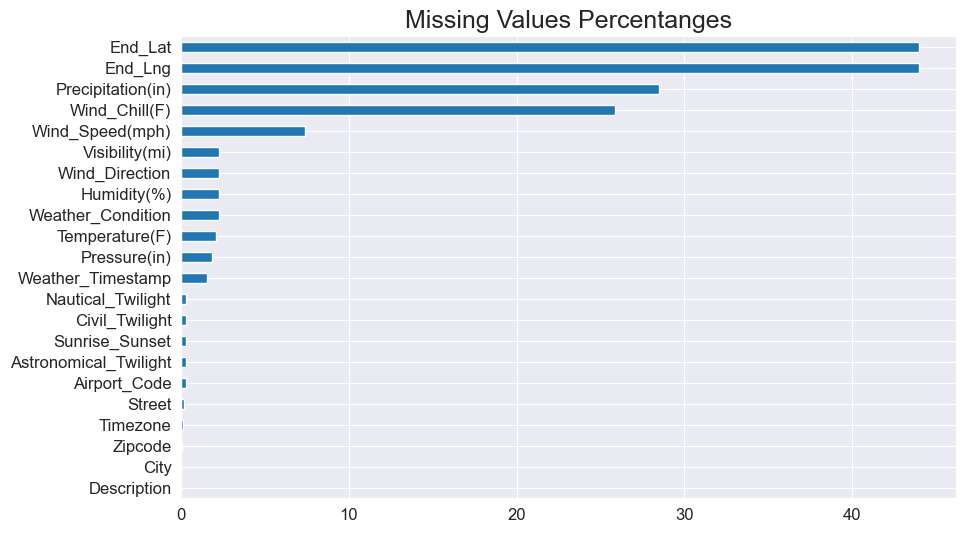

In [266]:
missing_percentages[missing_percentages != 0].sort_values().plot(kind="barh")
plt.title("Missing Values Percentanges")
plt.show()

### Removeving Useless olumns

In [10]:
df_sample.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [306]:
# List of relevant columns usefull for EDA
new_columns = [
    "ID",
    "City",
    "State",
    "Severity",
    "Start_Time",
    "Start_Lat",
    "Start_Lng",
    "Distance(mi)",
    "Temperature(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)",
    "Weather_Condition",
]

In [307]:
# Create a new DataFrame with only the relevant columns and make an explicit copy
df = df_sample[new_columns].copy()

In [298]:
df

,ID,City,State,Severity,Start_Time,Start_Lat,Start_Lng,Distance(mi),Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Weather_Condition
0,A-84486,Anaheim,CA,2,2016-10-17 09:21:17,33.853855,-117.955376,0.010,66.0,93.0,29.97,4.0,4.6,0.01,Light Rain
1,A-59894,Los Angeles,CA,2,2016-12-30 21:18:01,34.077187,-118.281334,0.010,57.9,93.0,29.96,7.0,NaN,NaN,Overcast
2,A-98035,Sherman Oaks,CA,2,2016-03-27 14:24:58,34.160980,-118.469437,0.010,73.9,45.0,29.95,10.0,9.2,NaN,Clear
3,A-25419,San Mateo,CA,2,2016-10-19 20:13:11,37.553181,-122.294724,0.010,66.2,37.0,30.13,10.0,73.6,NaN,Mostly Cloudy
4,A-79958,Anaheim,CA,2,2016-09-27 14:00:02,33.849445,-117.834862,0.000,93.0,20.0,29.81,10.0,9.2,NaN,Clear
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2318513,A-7769019,Dallas,TX,3,2019-08-05 11:13:40,32.741730,-96.919300,0.736,86.0,61.0,29.25,10.0,3.0,0.00,Partly Cloudy
2318514,A-7768168,Lodi,CA,2,2019-08-02 09:24:56,38.137320,-121.257820,0.204,72.0,59.0,29.99,10.0,6.0,0.00,Fair
2318515,A-7776144,Juntura,OR,2,2019-08-20 16:00:48,43.777645,-117.813621,1.367,92.0,13.0,25.75,10.0,0.0,0.00,Fair
2318516,A-7777376,Secaucus,NJ,2,2019-08-23 16:26:02,40.778860,-74.056800,0.354,75.0,53.0,29.97,10.0,3.0,0.00,Fair


## EDA

### Feature Relationships

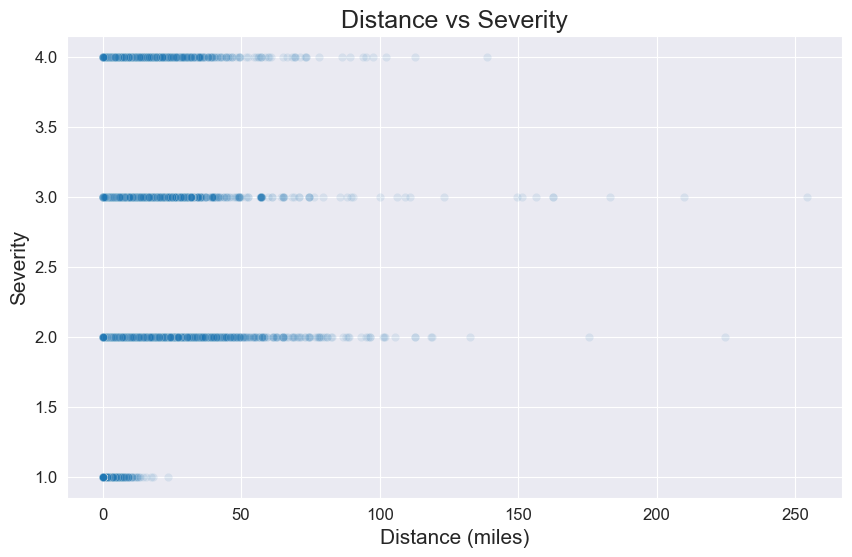

In [267]:
sns.scatterplot(x="Distance(mi)", y="Severity", data=df, alpha=0.1)
plt.title("Distance vs Severity")
plt.xlabel("Distance (miles)")
plt.ylabel("Severity")
plt.show()

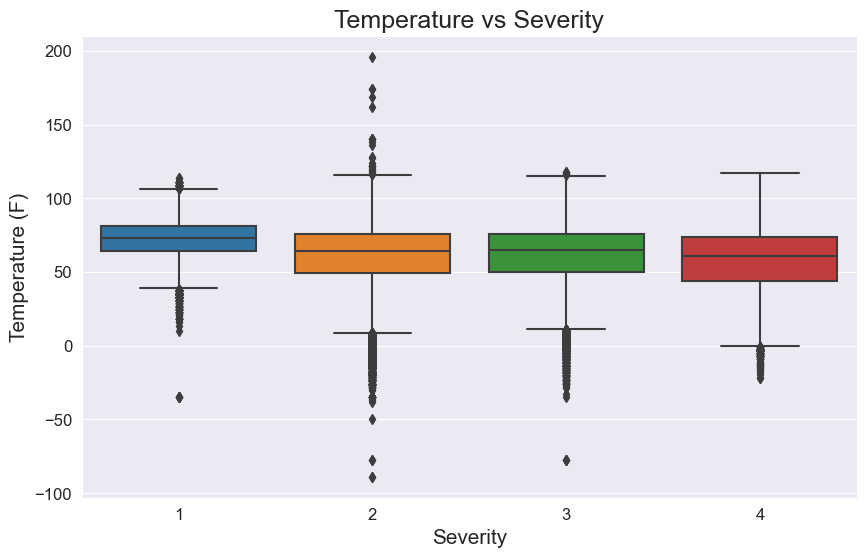

In [268]:
sns.boxplot(x="Severity", y="Temperature(F)", data=df)
plt.title("Temperature vs Severity")
plt.xlabel("Severity")
plt.ylabel("Temperature (F)")
plt.show()

### What is the Frequency of each Severity Level?

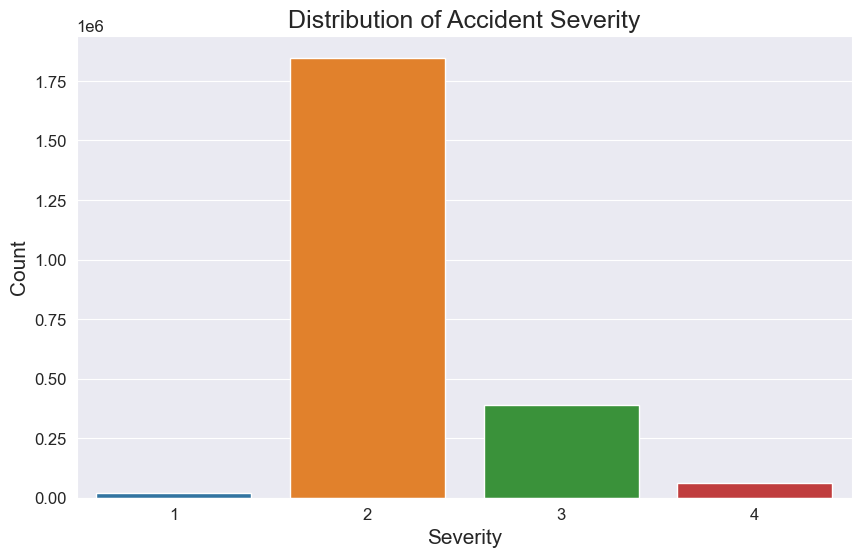

In [270]:
sns.countplot(x="Severity", data=df)
plt.title("Distribution of Accident Severity")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.show()

### Areas with high Accident Concentrations

In [275]:
sample_df = df.sample(int(0.1 * len(df)))

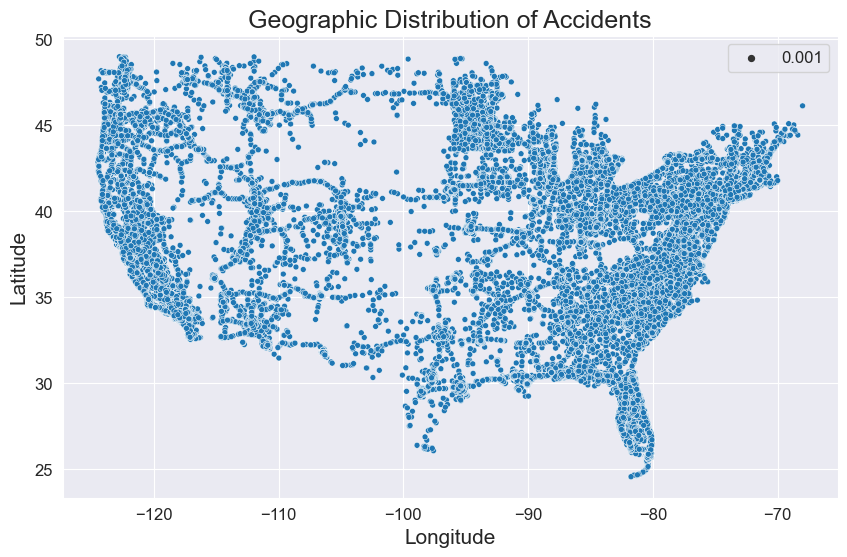

In [276]:
sns.scatterplot(x=sample_df.Start_Lng, y=sample_df.Start_Lat, size=0.001)
plt.title("Geographic Distribution of Accidents")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### Cities with More Accidents

In [124]:
df.City.value_counts()

City
Miami                 55792
Houston               50783
Los Angeles           47081
Charlotte             41824
Dallas                39349
                      ...  
Buckfield                 1
Duck Creek Village        1
Sandy Lake                1
Okauchee                  1
Montour                   1
Name: count, Length: 12157, dtype: int64

In [129]:
# Identify the top 10 cities by number of accidents
top_10_cities = df[df["City"].value_counts().head(10).index]

# Filter the DataFrame to keep only the rows where the City is one of the top 10 cities
df_top_10 = df[df["City"].isin(top_10_cities)]

In [130]:
agg_data_top_10 = df_top_10.groupby("City").agg(
    {
        "Temperature(F)": ["mean", "max", "count", "sum"],
        "Humidity(%)": ["mean", "max", "count", "sum"],
    }
)

In [132]:
# Flatten the MultiIndex columns
agg_data_top_10.columns = ["_".join(col) for col in agg_data_top_10.columns]
agg_data_top_10.reset_index(inplace=True)

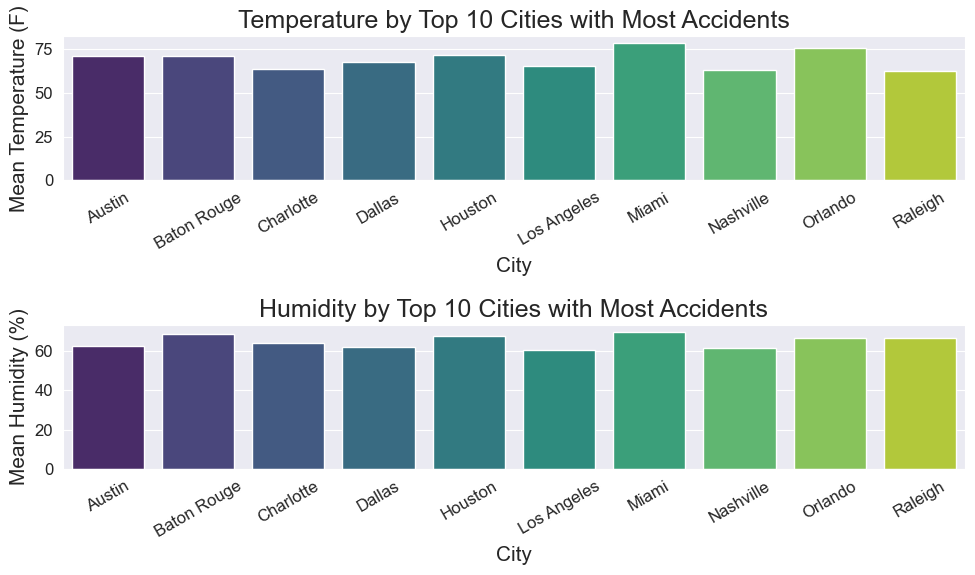

In [277]:
# Plot mean temperature by city
plt.subplot(2, 1, 1)
sns.barplot(x="City", y="Temperature(F)_mean", data=agg_data_top_10, palette="viridis")
plt.title("Temperature by Top 10 Cities with Most Accidents")
plt.xlabel("City")
plt.ylabel("Mean Temperature (F)")
plt.xticks(rotation=30)

# Plot mean humidity by city
plt.subplot(2, 1, 2)
sns.barplot(x="City", y="Humidity(%)_mean", data=agg_data_top_10, palette="viridis")
plt.title("Humidity by Top 10 Cities with Most Accidents")
plt.xlabel("City")
plt.ylabel("Mean Humidity (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [135]:
len(df.City.unique())

12158

In [154]:
cities_by_accident = df.City.value_counts()

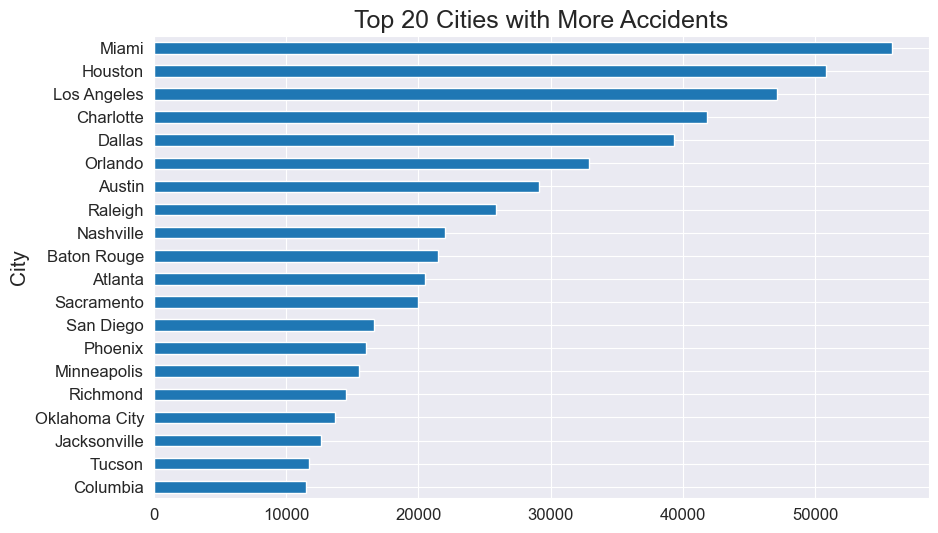

In [281]:
cities_by_accident[:20].sort_values().plot(kind="barh")
plt.title("Top 20 Cities with More Accidents")
plt.show()

In [101]:
"New York" in df.City

False

In [106]:
"NY" in df.State

False

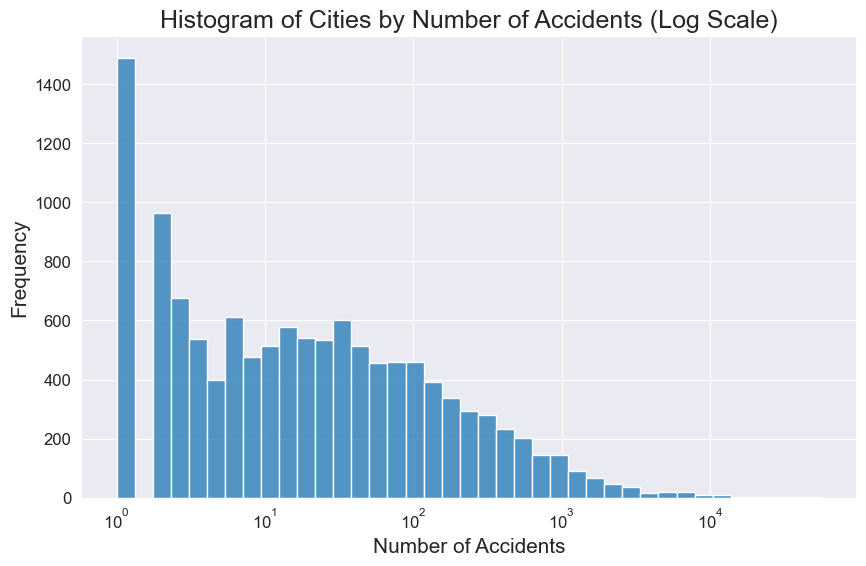

In [316]:
sns.histplot(data=df.City.value_counts(), log_scale=True)
plt.xlabel("Number of Accidents")
plt.ylabel("Frequency")
plt.title("Histogram of Cities by Number of Accidents (Log Scale)")
plt.show()

In [210]:
len(cities_by_accident[cities_by_accident == 1])

1489

In [211]:
high_accident_cities = cities_by_accident[cities_by_accident >= 1000]
low_accident_cities = cities_by_accident[cities_by_accident < 1000]

In [212]:
(len(high_accident_cities) / len(cities)) * 100

3.0350386576739594

In [213]:
(len(low_accident_cities) / len(cities)) * 100

96.95673630531337

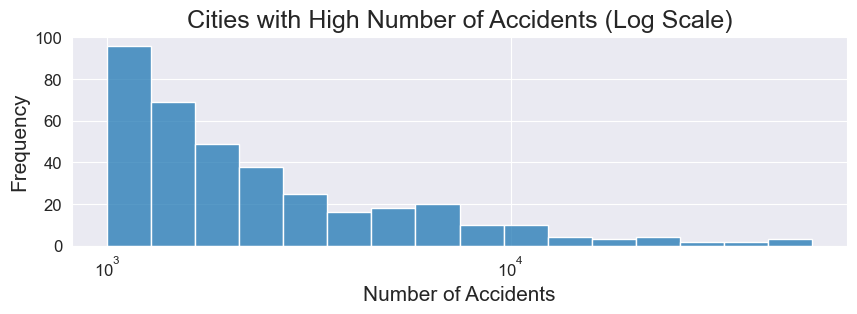

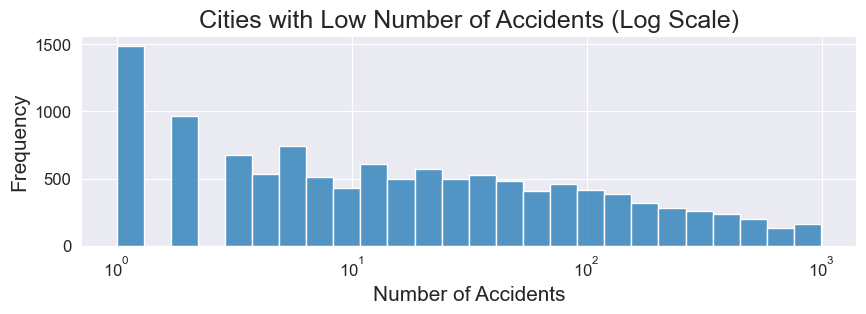

In [292]:
import warnings

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning)
    plt.subplot(2, 1, 1)
    sns.histplot(high_accident_cities, log_scale=True)
    plt.xlabel("Number of Accidents")
    plt.ylabel("Frequency")
    plt.title("Cities with High Number of Accidents (Log Scale)")
    plt.show()

    plt.subplot(2, 1, 2)
    sns.histplot(low_accident_cities, log_scale=True)
    plt.xlabel("Number of Accidents")
    plt.ylabel("Frequency")
    plt.title("Cities with Low Number of Accidents (Log Scale)")
    plt.show()

### Which is the per capita accidents for the top 5 states with more accidents?

In [222]:
df["State"].value_counts().head(5)

State
CA    522186
FL    264198
TX    174941
SC    114851
NY    104060
Name: count, dtype: int64

In [248]:
# 2020 Census population data for each state
state_population = {
    "CA": 39538223,
    "FL": 21538187,
    "TX": 29145505,
    "SC": 5118425,
    "NY": 20201249,
}

In [249]:
# Calculate accidents per capita
accidents_per_state_df = df["State"].value_counts().head(5).reset_index()
accidents_per_state_df.columns = ["State", "Accidents"]

In [250]:
# Add population data to the dataframe
accidents_per_state_df["Population"] = accidents_per_state_df["State"].map(
    state_population
)

In [252]:
# Calculate accidents per capita (per 100,000 people)
accidents_per_state_df["Accidents_Per_Capita"] = (
    accidents_per_state_df["Accidents"] / accidents_per_state_df["Population"]
) * 100000

In [253]:
# Get the top 5 states by accidents per capita
top_5_accidents_per_capita = accidents_per_state_df.sort_values(
    by="Accidents_Per_Capita", ascending=False
)

In [257]:
top_5_accidents_per_capita

,State,Accidents,Population,Accidents_Per_Capita
3,SC,114851,5118425,2243.873848
0,CA,522186,39538223,1320.711859
1,FL,264198,21538187,1226.649207
2,TX,174941,29145505,600.233209
4,NY,104060,20201249,515.116664


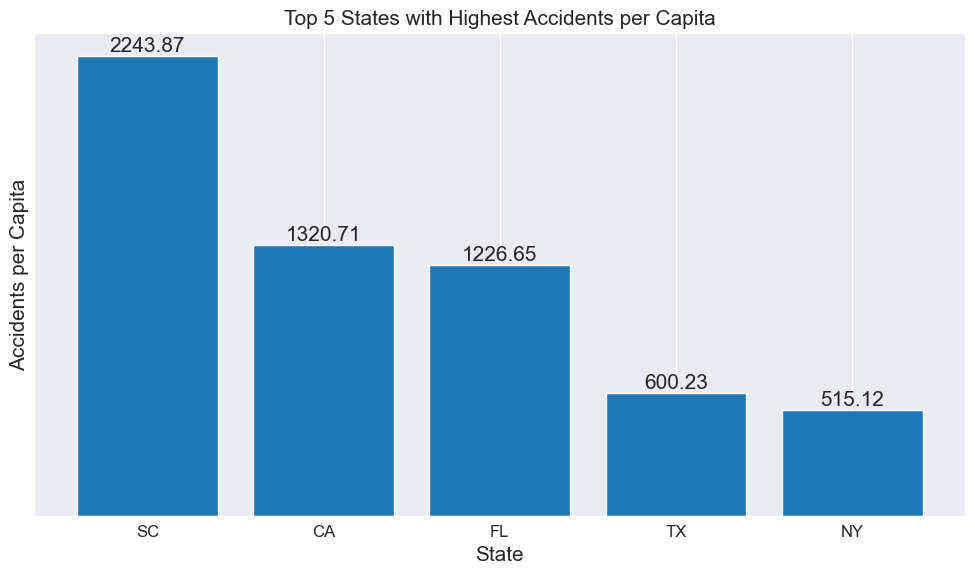

In [293]:
states = top_5_accidents_per_capita["State"]
accidents_per_capita = top_5_accidents_per_capita["Accidents_Per_Capita"]


bars = plt.bar(states, accidents_per_capita)
plt.title("Top 5 States with Highest Accidents per Capita", fontsize=15)
plt.xlabel("State", fontsize=15)
plt.ylabel("Accidents per Capita", fontsize=15)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
    )

# Remove y-axis line and ticks
ax = plt.gca()
ax.spines["left"].set_visible(False)
ax.yaxis.set_ticks([])

plt.tight_layout()
plt.show()

### What is the Impact of Weather?

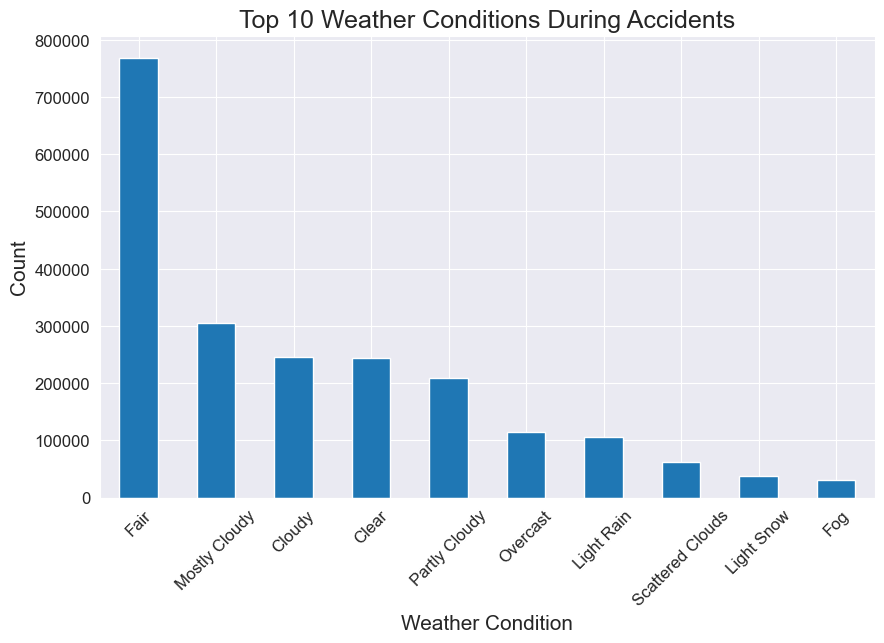

In [294]:
df["Weather_Condition"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Weather Conditions During Accidents")
plt.xlabel("Weather Condition")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Trends and peak times for accidents

In [161]:
df["Start_Time"].value_counts()

Start_Time
2021-01-26 16:16:13    65
2021-01-26 16:17:33    44
2021-02-16 06:42:43    39
2021-11-21 18:37:51    32
2021-02-16 06:43:35    28
                       ..
2019-01-13 17:52:27     1
2019-01-10 21:02:23     1
2019-01-29 10:07:18     1
2019-01-21 13:20:36     1
2019-08-28 22:10:00     1
Name: count, Length: 2102231, dtype: int64

In [30]:
# Get a sample of the problematic data to understand the format
df["Start_Time"].sample(20)

307917               2021-03-30 11:45:58
2087610              2020-05-14 10:35:30
2280524              2019-05-16 13:46:28
1023041              2017-01-03 11:59:43
204621               2022-05-20 17:32:17
490234               2020-02-25 08:23:22
991025               2017-08-10 18:41:59
308939               2021-06-10 08:07:16
1193191    2022-10-10 16:04:30.000000000
1351629    2022-07-21 08:28:00.000000000
1947834              2021-02-05 13:27:30
1036890              2016-11-08 04:29:21
1481639    2022-01-26 08:13:42.000000000
906185               2018-01-03 08:33:07
2096688              2020-05-03 16:50:22
1278353              2022-01-05 08:15:00
691379               2019-01-25 07:24:17
704465               2019-01-18 07:09:30
2005294              2020-10-23 16:05:00
1979072              2020-12-25 07:50:00
Name: Start_Time, dtype: object

In [308]:
# Remove extra characters ".000000000" if present
df["Start_Time"] = df["Start_Time"].str.replace(".000000000", "", regex=False)

In [309]:
# Convert Start_Time to datetime
df["Start_Time"] = pd.to_datetime(df["Start_Time"], format="mixed", errors="coerce")

In [310]:
print(df["Start_Time"].dtype)

datetime64[ns]


In [311]:
# Check for rows that couldn't be converted (if any)
invalid_times = df[df["Start_Time"].isnull()]
print(f"Number of invalid Start_Time entries: {len(invalid_times)}")

Number of invalid Start_Time entries: 0


In [ ]:
# # Drop rows with invalid datetime conversion
# df = df.dropna(subset=['Start_Time'])

In [312]:
# Extract year, month, day, and hour
df["Year"] = df["Start_Time"].dt.year
df["Month"] = df["Start_Time"].dt.month
df["Day"] = df["Start_Time"].dt.day
df["Hour"] = df["Start_Time"].dt.hour

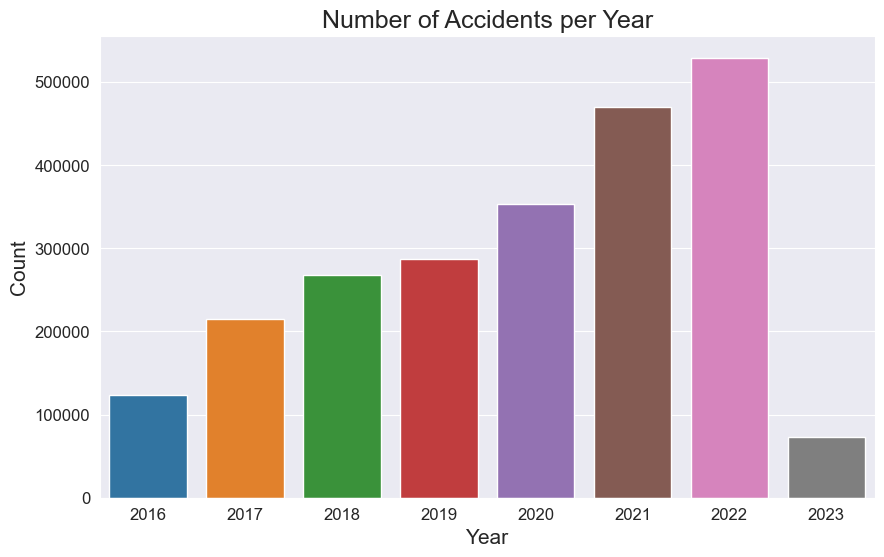

In [305]:
sns.countplot(x="Year", data=df)
plt.title("Number of Accidents per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

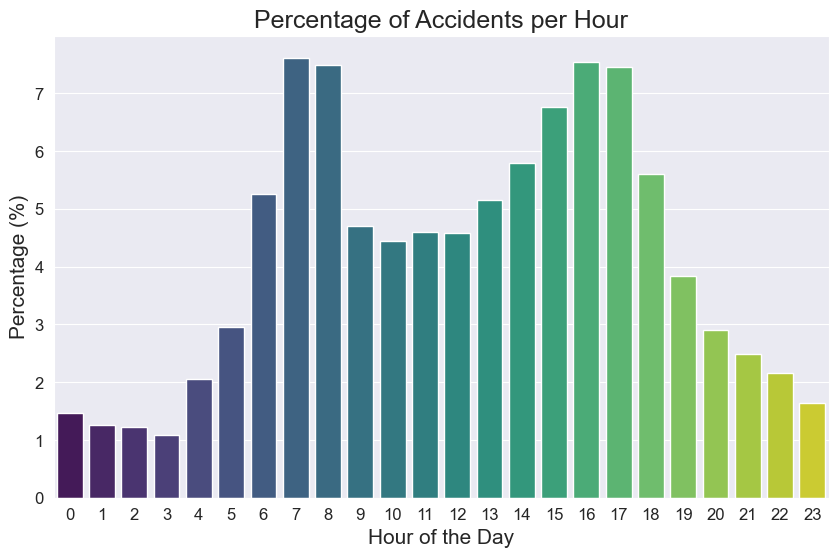

In [313]:
hour_counts = df["Hour"].value_counts(normalize=True).sort_index() * 100
sns.barplot(x=hour_counts.index, y=hour_counts.values, palette="viridis")
plt.title("Percentage of Accidents per Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Percentage (%)")
plt.show()

- A high percentage of accidents occur between 6 am to 10 am (probably people in a hurry to get to work)
- Next higest percentage is 3 pm to 6 pm.

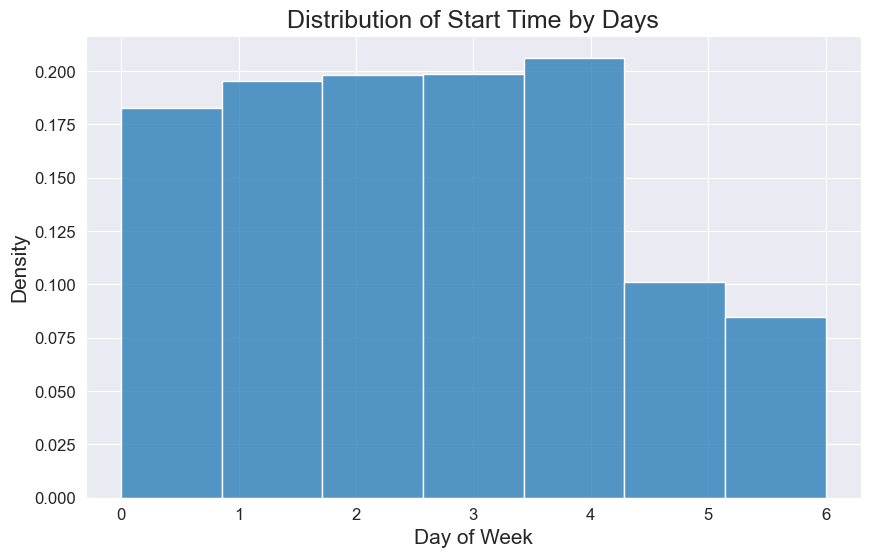

In [317]:
sns.histplot(df.Start_Time.dt.dayofweek, bins=7, kde=False, stat="density")
plt.xlabel("Day of Week")
plt.ylabel("Density")
plt.title("Distribution of Start Time by Days")
plt.show()

### What about the Weekends?

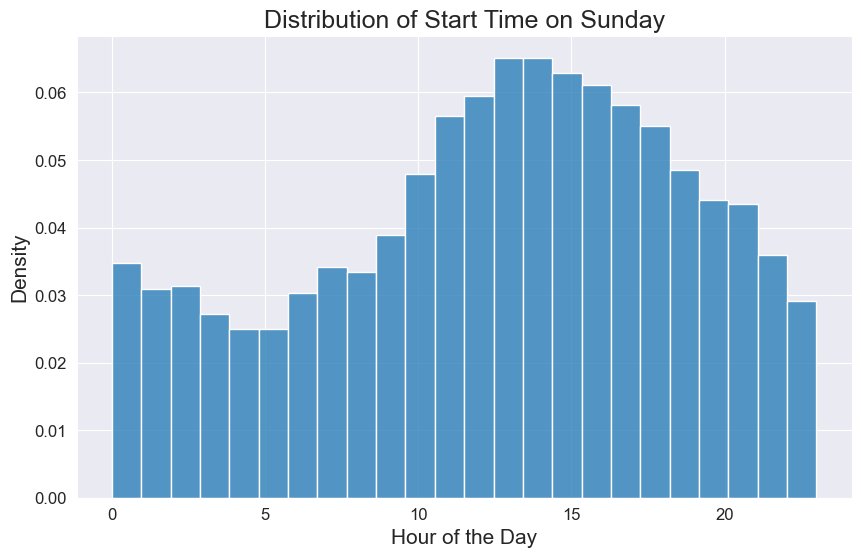

In [318]:
sundays_start_time = df.Start_Time[df.Start_Time.dt.dayofweek == 6]
sns.histplot(sundays_start_time.dt.hour, bins=24, kde=False, stat="density")
plt.xlabel("Hour of the Day")
plt.ylabel("Density")
plt.title("Distribution of Start Time on Sunday")
plt.show()

On Sundays, the peak occurs between 10 am and 3 pm, unlike weekdays

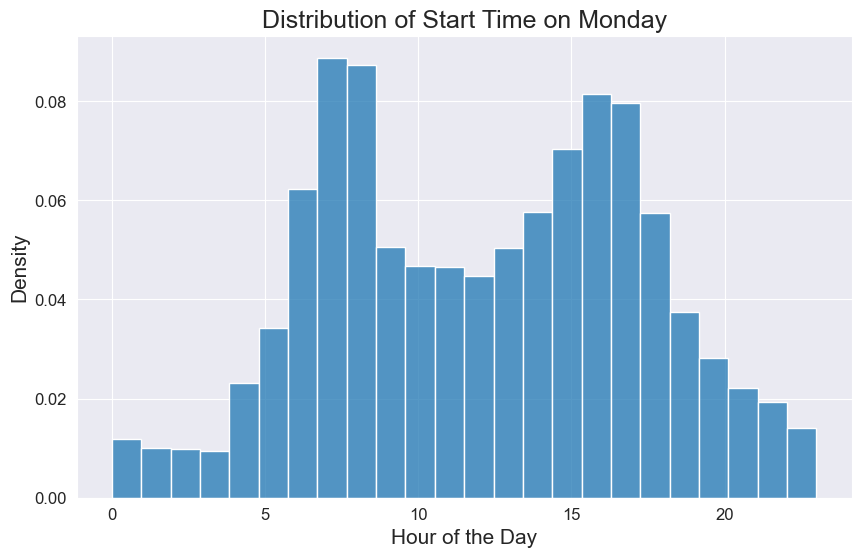

In [319]:
monday_start_time = df.Start_Time[df.Start_Time.dt.dayofweek == 0]
sns.histplot(monday_start_time.dt.hour, bins=24, kde=False, stat="density")
plt.xlabel("Hour of the Day")
plt.ylabel("Density")
plt.title("Distribution of Start Time on Monday")
plt.show()

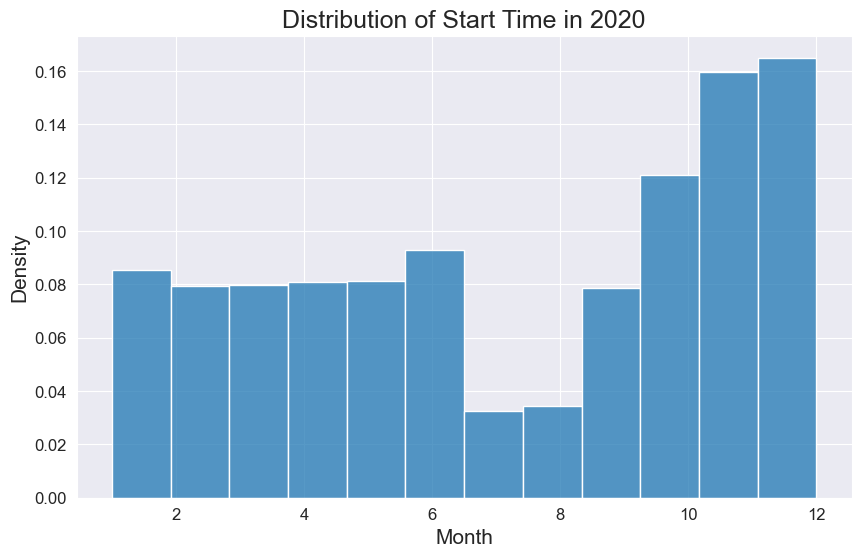

In [321]:
df_2020 = df[df.Start_Time.dt.year == 2020]
sns.histplot(df_2020.Start_Time.dt.month, bins=12, kde=False, stat="density")
plt.xlabel("Month")
plt.ylabel("Density")
plt.title("Distribution of Start Time in 2020")
plt.show()

In [320]:
import folium

lat, lon = df.Start_Lat[0], df.Start_Lng[0]
lat, lon

(33.853855, -117.955376)

In [196]:
for index, row in df[["Start_Lat", "Start_Lng"]].sample(100).iterrows():
    print(row["Start_Lat"], row["Start_Lng"])

27.243523 -80.860023
44.26042914369458 -117.1818816656247
33.960148 -118.244179
42.367298 -83.138481
34.124305 -118.632792
40.644118 -74.66770799999998
39.94553 -82.94272
43.783901 -88.481628
36.754488 -119.171276
37.507381 -120.956596
38.445869 -121.858505
30.394144 -97.746681
41.070854 -73.622824
42.968856 -73.81998
39.015234 -77.122782
33.152729 -80.05986
39.914078 -104.977844
33.766199 -117.932981
45.51724 -122.66482
34.08807 -118.23595
45.142143 -93.281654
30.443483 -97.833115
35.165401 -80.87769300000002
38.96208 -77.08029
37.255848 -121.955949
32.92494600000001 -96.998802
33.503059 -111.923332
29.923978 -90.008071
33.778836 -117.883897
30.380911 -91.096909
35.51859 -82.96736
38.801743 -77.112
39.592317 -75.678498
34.149466 -118.469084
40.718346 -73.408897
39.75421 -84.22416
40.6888 -73.80870999999998
28.333019 -81.48801800000003
34.521978000000004 -118.097385
34.26063895209188 -77.92788147889172
27.699369 -80.896622
40.096283 -75.168015
33.752135 -117.455359
29.029275 -82.15881


In [197]:
from folium.plugins import HeatMap

sample_df = df.sample(int(0.001 * len(df)))
lat_lon_pairs = list(zip(list(sample_df.Start_Lat), list(sample_df.Start_Lng)))

In [198]:
map = folium.Map()
HeatMap(lat_lon_pairs).add_to(map)
map

# Questions

1. Are there more accidents in warmer or colder areas?
2. Among the top 100 cities in number of accidents, which states do they belong to most frequently.
3. What time of the day are accidents most frequent in?
4. When is accidents per unit of traffic the highest.